In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils import data
import matplotlib.pyplot as plt
from collections import defaultdict

from tqdm import tqdm

In [2]:
df = torch.load(r'C:\Users\Admin\Documents\GitHub\PLUM_implementation\data\heterodata_object12_updated.pt', weights_only=False,map_location=torch.device('cpu'))

In [3]:
df

HeteroData(
  item={
    x=[12101, 100],
    text=[12101, 2],
    related=[12101],
    is_train=[12101],
  },
  (user, rated, item)={
    history={
      train={
        item_ID=[22363],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      valid={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      test={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
    },
  }
)

In [4]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim
        self.encoder = nn.Sequential()
        self.dims = [input_dim] + hidden_dims + [output_dim]
        for ind, inp_dim in enumerate(self.dims[:-1]):
            out_dim = self.dims[ind+1]
            cur_enc = nn.Linear(inp_dim, out_dim, bias = False)
            self.encoder.append(cur_enc)
            if ind != len(self.dims) - 2:
                self.encoder.append(nn.ReLU())
        
    def forward(self, x):
        return self.encoder(x)

In [5]:
class Codebook(nn.Module):
    def __init__(self, codebook_size, emb_dim, beta):
        super().__init__()
        self.beta = beta
        self.emb = nn.Embedding(codebook_size, emb_dim)
        nn.init.uniform_(self.emb.weight, -1.0, 1.0)

    def forward(self, x):
        code = self.emb.weight  
        dist = (
            (x ** 2).sum(dim=1, keepdim=True)
            + (code ** 2).sum(dim=1)
            - 2 * x @ code.T
        )
        ids = dist.argmin(dim=1)
        emb = self.emb(ids)
        loss = (
            F.mse_loss(emb, x.detach()) +
            self.beta * F.mse_loss(x, emb.detach())
        )
        emb_st = x + (emb - x).detach()
        return loss, emb_st, ids


In [6]:
class RQVAE(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim,n_codebooks, n_layers, beta):
        super().__init__()
        self.inp_size = inp_size
        self.hidden_sizes = hidden_sizes
        self.emb_dim = embed_dim
        self.enc = Encoder(inp_size, hidden_sizes, embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[-1::-1], inp_size)
        self.layers = nn.ModuleList(modules=[Codebook(n_codebooks, embed_dim, beta) for _ in range(n_layers)])
    
    def forward(self,x):
        encoded = self.enc(x)
        r = encoded
        q_losses = 0
        sids = []
        e_sum = torch.zeros(size=(x.shape[0], self.emb_dim), device = 'cuda' if torch.cuda.is_available() else 'cpu')
        for layer in self.layers:
            q_loss, emb, ids = layer(r)
            r = r-emb.detach()
            q_losses+= q_loss
            e_sum += emb
            sids.append(ids)
        dec = self.dec(e_sum)
        rec_loss = F.mse_loss(x, dec) 
        loss = q_losses + rec_loss
        return {"sids": sids, 
                "q_loss": q_losses,
                "r_loss": rec_loss,
                "loss": loss}   
            
            

In [7]:
class RQVAE_modified(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_layers, beta):
        super().__init__()
        self.inp_size = inp_size
        self.hidden_sizes = hidden_sizes
        self.emb_dim = embed_dim
        self.enc = Encoder(inp_size, hidden_sizes, embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[-1::-1], inp_size)
        self.layers = nn.ModuleList(modules=[Codebook(2048//(2**i), embed_dim, beta) for i in range(n_layers)])
    
    def forward(self,x, related):
        encoded = self.enc(x)
        rel_encoded = self.enc(related)
        r = encoded
        q_losses = 0
        sids = []
        e_sum = torch.zeros_like(encoded)
        level_mask = torch.randint(1, len(self.layers)+1, size=(1,)).item()
        for level, layer in enumerate(self.layers):
            mask = level < level_mask
            q_loss, emb, ids = layer(r)
            r = r-emb.detach()
            q_losses+= q_loss
            e_sum += emb * mask
            sids.append(ids)
        dec = self.dec(e_sum)
        rec_loss = F.mse_loss(x, dec) 
        sims = encoded @ rel_encoded.T
        log_probs = F.log_softmax(sims, dim=1)
        con_loss = -torch.diag(log_probs).mean()
        loss = q_losses + rec_loss + con_loss
        return {"sids": sids, 
                "q_loss": q_losses,
                "r_loss": rec_loss,
                "con_loss": con_loss,
                "loss": loss}   

In [8]:
class Data_Embeddings(Dataset):
    def __init__(self, embed, related):
        super().__init__()
        self.embed = embed
        self.related = related
        
    def __getitem__(self, index):
        rel_id = self.related[index]
        if len(rel_id) == 0:
            rel_embed = self.embed[index]
        else:
            rel_embed = self.embed[np.random.choice(rel_id)]
        return rel_embed, self.embed[index]
        
    def __len__(self):
        return self.embed.shape[0]

In [9]:
def unique_per_level(SIDs):
    uns = []
    for sid in SIDs:
        uns.append(sid.unique().numel())
    return torch.tensor(uns, device = device)

In [10]:
def entropy_per_level(all_sids, codebook_size):
    entropies = []

    for level_ids in all_sids:
        ids = torch.cat(level_ids).view(-1)
        counts = torch.bincount(ids, minlength=codebook_size).float()
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropy = -(probs * torch.log2(probs)).sum()
        entropies.append(entropy)

    return torch.tensor(entropies, device='cpu').detach()


In [11]:
embeds = df['item'].x
related = df['item'].related
ds = Data_Embeddings(embeds, related)

In [12]:
train_rq, val_rq = data.random_split(ds, [0.9, 0.1])
print(len(val_rq))

1210


In [13]:
dl_train_rq = DataLoader(train_rq, batch_size = 1024, shuffle = True)
dl_val_rq = DataLoader(val_rq, batch_size = len(val_rq), shuffle= False)

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [15]:
lr = 0.4
n_layers = 3
beta = 0.25
hidden_sizes = [512, 256, 128]
embed_dim = 32
codebook_num = 2048
n_ep = 100

In [17]:
history_mod = {}
for session in range(1, 8):
    conf_i = torch.load(f'Downloads/checkpoint_{session}.pt', 
                        map_location=device)
    hist_i = conf_i['history']
    for key, values in hist_i.items():
        if key not in history_mod:
            history_mod[key] = []
        history_mod[key].extend(values)


In [18]:
rq_vae_mod = RQVAE_modified(embeds.shape[1], hidden_sizes, embed_dim, n_layers, beta).to(device)
rq_vae_mod.load_state_dict(conf_i['model_state'])

<All keys matched successfully>

In [19]:
rq_vae = RQVAE(embeds.shape[1], hidden_sizes, embed_dim, codebook_num, n_layers, beta).to(device)
rq_vae.load_state_dict(torch.load(r'C:\Users\Admin\Documents\GitHub\PLUM_implementation\data\best_rqvae.pth',map_location = device))

<All keys matched successfully>

In [20]:
def sids_analyze(model, ds, device):
    model.eval()
    sid_to_ids = defaultdict(list)
    id_to_sid = {}
    loss_total_avg = 0 
    with torch.no_grad():
        for item_id in range(len(ds)):
            embed_rel, embed  = ds[item_id][0], ds[item_id][1]
            embed_rel = embed_rel.to(device).view(1,-1)
            embed = embed.to(device).view(1,-1)
            if isinstance(model, RQVAE):
                pred = model(embed)
            else:
                pred = model(embed, embed_rel)
            sids = pred['sids']
            loss_total =  pred['loss']
            loss_total_avg += loss_total 
            sid_tuple = tuple(level.item() for level in sids)
            sid_to_ids[sid_tuple].append(item_id)
            id_to_sid[item_id] = sid_tuple

    id_to_fullsid = {}
    loss_total_avg = loss_total_avg/len(ds)
    for sid, ids in sid_to_ids.items():
        if len(ids) == 1:
            id_to_fullsid[ids[0]] = sid
        else:
            for cnt, item_id in enumerate(ids):
                id_to_fullsid[item_id] = (*sid, cnt)
                
    return {
        "id_to_sid": id_to_sid,
        "sid_to_ids": sid_to_ids,
        "id_to_fullsid": id_to_fullsid,
        'total_loss': loss_total_avg.item()
    }



In [21]:
def calculate_metrics(sid_to_ids, ds, total_loss):
    n_unique_sid = len(sid_to_ids)
    n_collisions = sum(len(v) - 1 for v in sid_to_ids.values())
    max_cluster = max(len(v) for v in sid_to_ids.values())
    cfr = (len(ds) - n_collisions) / len(ds)
    return {'n_unique_sid': n_unique_sid,
            'n_collisions': n_collisions,
            'max_cluster': max_cluster,
            'collision_free_ratio': cfr,
           'total_loss': total_loss}
            

In [22]:
rq_vae_sids = sids_analyze(rq_vae, ds, device)
rq_vae_mod_sids = sids_analyze(rq_vae_mod, ds, device)

In [23]:
metrics_rq_vae = calculate_metrics(rq_vae_sids['sid_to_ids'], ds, rq_vae_sids['total_loss'])
metrics_rq_vae_mod = calculate_metrics(rq_vae_mod_sids['sid_to_ids'],ds,rq_vae_mod_sids['total_loss'])
metrics = {'RQ_VAE': metrics_rq_vae,
            'RQ_VAE_MODIFIED': metrics_rq_vae_mod}

In [24]:
stats = pd.DataFrame(metrics).T
stats

,n_unique_sid,n_collisions,max_cluster,collision_free_ratio,total_loss
RQ_VAE,11092.0,1009.0,9.0,0.916618,22.065248
RQ_VAE_MODIFIED,2940.0,9161.0,487.0,0.242955,0.217155


In [25]:
def plot_losses(history):
    epochs = range(1, len(history["train_total_loss"]) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_total_loss"], label="train total")
    plt.plot(epochs, history["val_total_loss"], label="val total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total loss")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_recon_loss"], label="train recon")
    plt.plot(epochs, history["train_rq_loss"], label="train quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train losses")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_recon_loss"], label="val recon")
    plt.plot(epochs, history["val_rq_loss"], label="val quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Val losses")
    plt.yscale("log")
    plt.legend()
    plt.savefig(fname = 'res_2.png')
    plt.show()


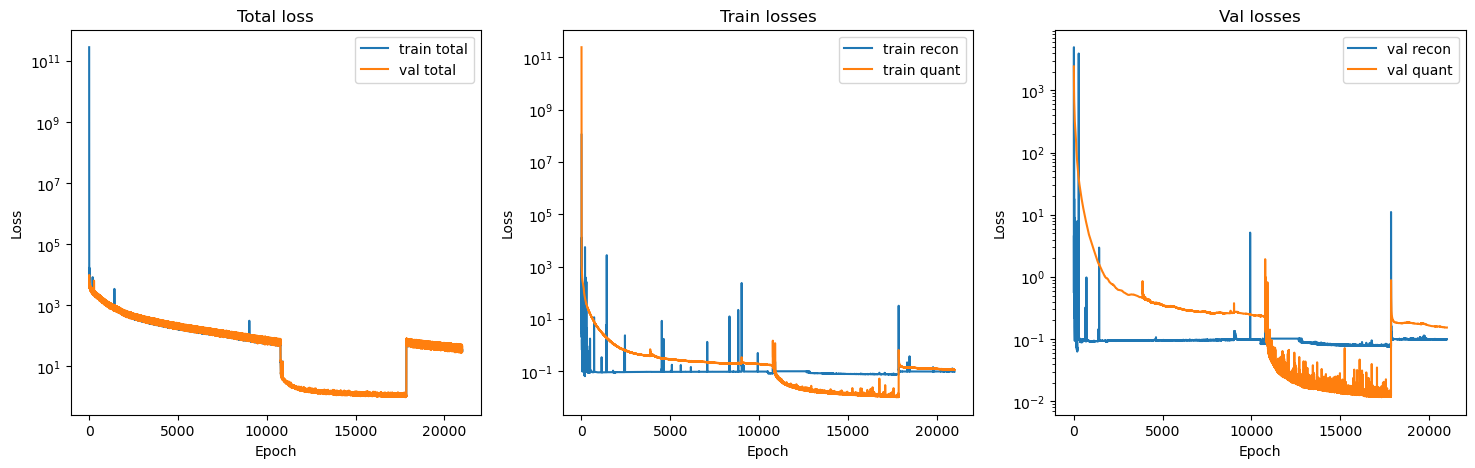

In [26]:
plot_losses(history_mod)

In [27]:
def plot_SIDS(history):
    epochs = range(1, len(history["val_sids_num"]) + 1)
    sids_val, sids_train = np.asarray(history["val_sids_num"]), np.asarray(history["train_sids_num"])
    
    plt.figure(figsize= (18, 12))
    for i in range(sids_val.shape[1]):
        plt.subplot(3, 1, i+1)
        
        plt.plot(epochs, sids_train[:, i], label=f"train sids level {i}")
        plt.plot(epochs, sids_val[:, i], label=f"val sids number {i}")
        plt.xlabel("Epoch")
        plt.ylabel("SID number")
        plt.legend()
    plt.savefig(fname = 'sids_plot.png')
    plt.show()

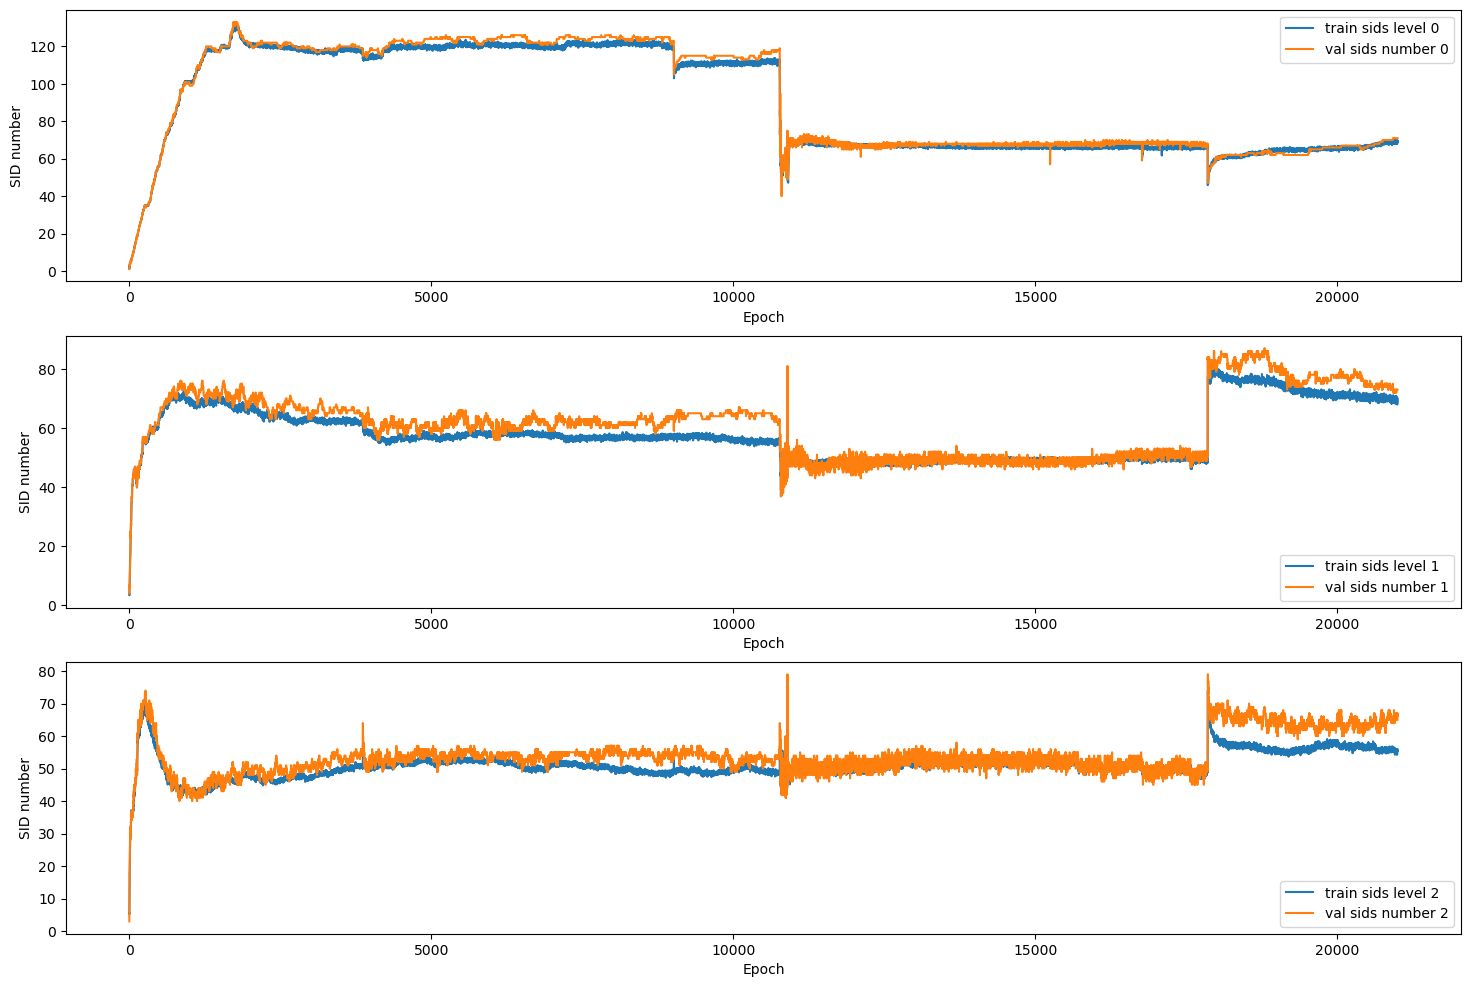

In [28]:
plot_SIDS(history_mod)

In [29]:
def plot_entropy(history):
    epochs = range(1, len(history["val_entropy"]) + 1)

    entropy_train = np.asarray(history["train_entropy"])
    entropy_val = np.asarray(history["val_entropy"])

    plt.figure(figsize=(18, 12))

    for i in range(entropy_val.shape[1]):
        plt.subplot(entropy_val.shape[1], 1, i + 1)

        plt.plot(epochs, entropy_train[:, i], label=f"train entropy level {i}")
        plt.plot(epochs, entropy_val[:, i], label=f"val entropy level {i}")

        plt.xlabel("Epoch")
        plt.ylabel("Entropy")
        plt.legend()

    plt.savefig('entropy_plot.png')
    plt.show()


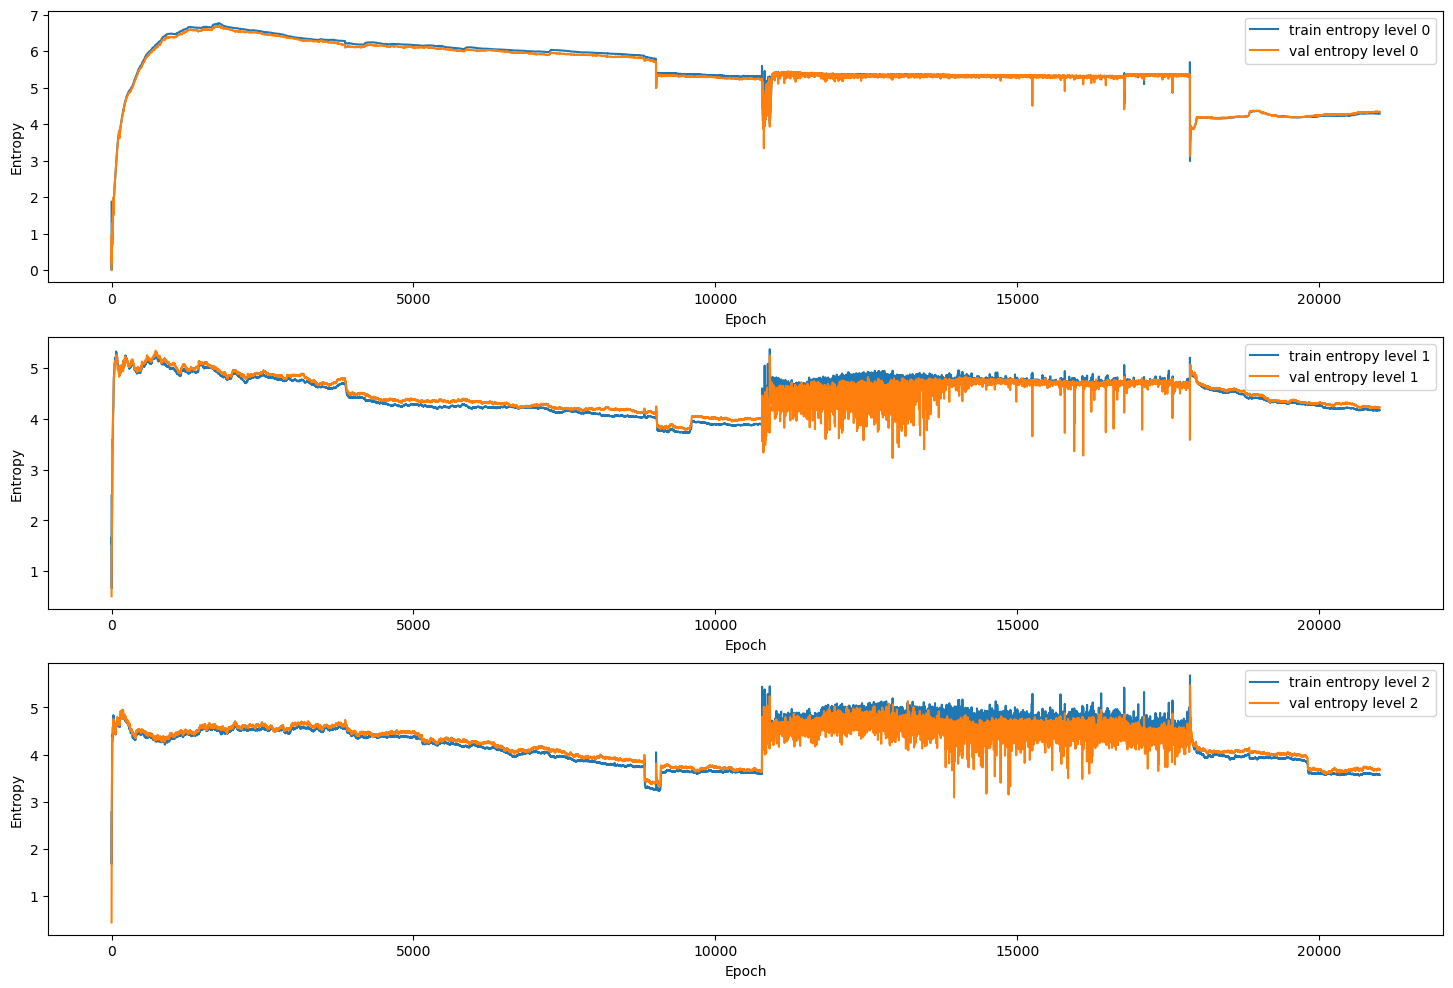

In [30]:
plot_entropy(history_mod)